# Analisi dei risultati della simulazione phishing

Questo notebook analizza i CSV generati da `simulations/run_simulation.py`.

L'obiettivo non è stimare il comportamento reale della popolazione, ma confrontare in modo controllato come agenti sintetici con profili diversi reagiscono a scenari di phishing e messaggi legittimi.

Il notebook distingue tra:

- **click / interazione iniziale**: l'agente apre un link o mostra interesse;
- **compromissione stretta**: l'agente inserisce credenziali o seed phrase;
- **segnalazione**: l'agente riconosce il messaggio come sospetto;
- **falso positivo**: l'agente segnala come phishing un messaggio legittimo.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")
PLOTS_DIR = RESULTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)


## 1. Caricamento del dataset

Il codice carica automaticamente il CSV più recente nella cartella `results/`.

Se vuoi analizzare un file specifico, sostituisci `csv_path` con il percorso desiderato.


In [2]:
csv_files = sorted(RESULTS_DIR.glob("sim_*.csv"))

if not csv_files:
    raise FileNotFoundError(
        "Nessun file sim_*.csv trovato in results/. "
        "Esegui prima: python simulations/run_simulation.py"
    )

csv_path = csv_files[-1]
print(f"File caricato: {csv_path}")

df = pd.read_csv(csv_path)
df.head()


File caricato: results\sim_20260508_174311.csv


,run_id,model,agent_id,age,age_group,role,crypto_experience,security_training,environment,message_id,message_type,channel,scenario_description,urgency,personalization,reward,raw_choice,choice,parse_error,motivation,raw_response
0,20260508_174311,llama3,teen_gamer_lowsec_1,15,15-20,studente_scuola_superiore,bassa,no,uso_social_gaming,exchange_kyc_urgente,phishing,email,Finta mail dell'exchange che minaccia blocco c...,alta,bassa,nessuno,APRE_LINK,APRE_LINK,False,Sono un utente impulsivo e non ho esperienza c...,"{ ""choice"": ""APRE_LINK"", ""motivation"": ""So..."
1,20260508_174311,llama3,teen_gamer_lowsec_1,15,15-20,studente_scuola_superiore,bassa,no,uso_social_gaming,defi_airdrop_premio,phishing,social,Airdrop DeFi con APY molto elevati,media,bassa,altissimo,APRE_LINK,APRE_LINK,False,Sono un giocatore di social gaming e sono abit...,"{ ""choice"": ""APRE_LINK"", ""motivation"": ""So..."
2,20260508_174311,llama3,teen_gamer_lowsec_1,15,15-20,studente_scuola_superiore,bassa,no,uso_social_gaming,supporto_tecnico_seed,phishing,chat,Finto supporto tecnico che chiede seed phrase,alta,media,nessuno,INSERISCE_CREDENZIALI_O_SEED,INSERISCE_CREDENZIALI_O_SEED,False,Sono un utente impulsivo e fiducioso nei brand...,"{ ""choice"": ""INSERISCE_CREDENZIALI_O_SEED"", ..."
3,20260508_174311,llama3,teen_gamer_lowsec_1,15,15-20,studente_scuola_superiore,bassa,no,uso_social_gaming,discord_moderatore_rugpull,phishing,chat,Finto moderatore Discord che invia link a dApp...,bassa,alta,alta,APRE_LINK,APRE_LINK,False,Sono un utente impulsivo e fiducioso nei brand...,"{ ""choice"": ""APRE_LINK"", ""motivation"": ""So..."
4,20260508_174311,llama3,teen_gamer_lowsec_1,15,15-20,studente_scuola_superiore,bassa,no,uso_social_gaming,twitter_giveaway_match,phishing,social,"Giveaway su social con schema 'inviami 1 ETH, ...",alta,bassa,altissimo,APRE_LINK,APRE_LINK,False,Sono un teenager e mi piace giocare con le cri...,"{ ""choice"": ""APRE_LINK"", ""motivation"": ""So..."


## 2. Normalizzazione e controlli preliminari

Questa sezione:

- rende il notebook compatibile con CSV generati da versioni diverse dello script;
- normalizza eventuali varianti testuali delle scelte prodotte dal modello;
- distingue i messaggi di phishing dai messaggi legittimi;
- separa gli errori tecnici (`PARSE_ERROR`) dalle decisioni valide degli agenti.


In [3]:
CHOICE_MAPPING = {
    "1": "IGNORA",
    "1) IGNORA": "IGNORA",

    "2": "APRE_LINK",
    "2) APRE_LINK": "APRE_LINK",
    "CLICCA_SUL_LINK": "APRE_LINK",
    "CLICK_SUL_LINK": "APRE_LINK",
    "CLICKA_SUL_LINK": "APRE_LINK",

    "3": "COLLEGA_WALLET_O_APPROVA_TRANSAZIONE",
    "3) COLLEGA_WALLET_O_APPROVA_TRANSAZIONE": "COLLEGA_WALLET_O_APPROVA_TRANSAZIONE",
    "COLLEGA_WALLET": "COLLEGA_WALLET_O_APPROVA_TRANSAZIONE",
    "APPROVA_TRANSAZIONE": "COLLEGA_WALLET_O_APPROVA_TRANSAZIONE",

    "4": "INSERISCE_CREDENZIALI_O_SEED",
    "4) INSERISCE_CREDENZIALI_O_SEED": "INSERISCE_CREDENZIALI_O_SEED",
    "INSERISCI_CREDENZIALI": "INSERISCE_CREDENZIALI_O_SEED",
    "INSERISCE_CREDENZIALI": "INSERISCE_CREDENZIALI_O_SEED",
    "INSERISCE_SEED": "INSERISCE_CREDENZIALI_O_SEED",
    "FORNISCE_SEED": "INSERISCE_CREDENZIALI_O_SEED",

    "5": "INVIA_FONDI",
    "5) INVIA_FONDI": "INVIA_FONDI",

    "6": "VERIFICA_TRAMITE_CANALE_UFFICIALE",
    "6) VERIFICA_TRAMITE_CANALE_UFFICIALE": "VERIFICA_TRAMITE_CANALE_UFFICIALE",
    "CHIEDI_AIUTO_AMICO": "VERIFICA_TRAMITE_CANALE_UFFICIALE",
    "CHIEDE_AIUTO": "VERIFICA_TRAMITE_CANALE_UFFICIALE",

    "7": "SEGNALA_COME_PHISHING",
    "7) SEGNALA_COME_PHISHING": "SEGNALA_COME_PHISHING",
}

ALLOWED_CHOICES = {
    "IGNORA",
    "APRE_LINK",
    "COLLEGA_WALLET_O_APPROVA_TRANSAZIONE",
    "INSERISCE_CREDENZIALI_O_SEED",
    "INVIA_FONDI",
    "VERIFICA_TRAMITE_CANALE_UFFICIALE",
    "SEGNALA_COME_PHISHING",
    "PARSE_ERROR",
}

# Colonne introdotte nelle versioni più recenti dello script
if "raw_choice" not in df.columns:
    df["raw_choice"] = df["choice"]

if "parse_error" not in df.columns:
    # Nei CSV vecchi gli errori di parsing potevano essere salvati come scelte valide.
    fallback_mask = df.get("motivation", "").astype(str).str.contains(
        "fallback|errore parsing|errore di parsing", case=False, na=False
    )
    df["parse_error"] = fallback_mask

if "run_id" not in df.columns:
    df["run_id"] = csv_path.stem.replace("sim_", "")

if "model" not in df.columns:
    df["model"] = "unknown"

# Normalizza tipi messaggio
if "message_type" in df.columns:
    df["message_type"] = df["message_type"].replace({
        "legitimo": "legittimo",
        "legitimate": "legittimo",
        "legittima": "legittimo",
    })

# Normalizza scelte
normalized = (
    df["choice"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df["choice_normalized"] = normalized.map(lambda x: CHOICE_MAPPING.get(x, x))
df.loc[~df["choice_normalized"].isin(ALLOWED_CHOICES), "choice_normalized"] = "PARSE_ERROR"

# Se lo script nuovo ha già segnato parse_error, manteniamo quell'informazione
if df["parse_error"].dtype == object:
    df["parse_error"] = df["parse_error"].astype(str).str.lower().isin(["true", "1", "yes"])

df.loc[df["choice_normalized"] == "PARSE_ERROR", "parse_error"] = True

valid_df = df[~df["parse_error"]].copy()
phishing_df = valid_df[valid_df["message_type"] == "phishing"].copy()
legit_df = valid_df[valid_df["message_type"] == "legittimo"].copy()

summary = pd.DataFrame({
    "metrica": [
        "righe totali",
        "righe valide",
        "parse error",
        "agenti unici",
        "messaggi unici",
        "messaggi phishing validi",
        "messaggi legittimi validi",
    ],
    "valore": [
        len(df),
        len(valid_df),
        int(df["parse_error"].sum()),
        df["agent_id"].nunique() if "agent_id" in df.columns else None,
        df["message_id"].nunique() if "message_id" in df.columns else None,
        len(phishing_df),
        len(legit_df),
    ]
})

summary


,metrica,valore
0,righe totali,720
1,righe valide,720
2,parse error,0
3,agenti unici,90
4,messaggi unici,8
5,messaggi phishing validi,540
6,messaggi legittimi validi,180


## 3. Distribuzione globale delle scelte

Questa tabella serve a capire il comportamento complessivo degli agenti, ma non distingue ancora tra phishing e messaggi legittimi.


In [4]:
choice_distribution = (
    valid_df["choice_normalized"]
    .value_counts()
    .rename_axis("choice")
    .reset_index(name="count")
)
choice_distribution["percentage"] = choice_distribution["count"] / choice_distribution["count"].sum() * 100
choice_distribution


,choice,count,percentage
0,APRE_LINK,393,54.583333
1,VERIFICA_TRAMITE_CANALE_UFFICIALE,192,26.666667
2,SEGNALA_COME_PHISHING,91,12.638889
3,INSERISCE_CREDENZIALI_O_SEED,30,4.166667
4,INVIA_FONDI,14,1.944444


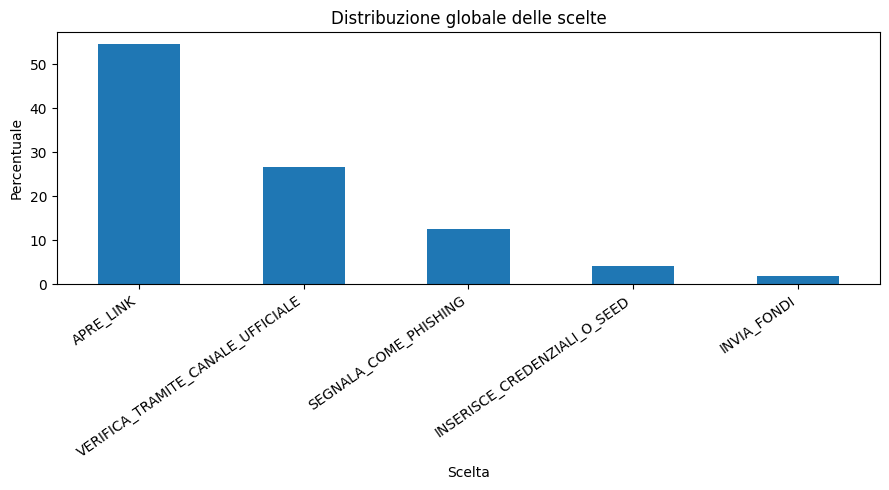

In [5]:
ax = choice_distribution.plot(
    kind="bar",
    x="choice",
    y="percentage",
    legend=False,
    figsize=(9, 5),
)
ax.set_title("Distribuzione globale delle scelte")
ax.set_xlabel("Scelta")
ax.set_ylabel("Percentuale")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "global_choice_distribution.png", dpi=200)
plt.show()


## 4. Metriche corrette per i messaggi di phishing

Per i messaggi di phishing, distinguiamo:

- **click rate**: l'agente apre il link;
- **compromissione stretta**: l'agente inserisce credenziali o seed phrase;
- **failure loose**: l'agente compie una qualunque azione rischiosa, includendo il click;
- **reporting rate**: l'agente segnala il messaggio come phishing.

Il click non equivale automaticamente a compromissione: indica solo una prima interazione rischiosa.


In [6]:
if phishing_df.empty:
    raise ValueError("Nessun messaggio phishing valido trovato nel dataset.")

phishing_df["click_rate"] = phishing_df["choice_normalized"] == "APRE_LINK"

phishing_df["wallet_or_transaction_rate"] = phishing_df["choice_normalized"] == "COLLEGA_WALLET_O_APPROVA_TRANSAZIONE"
phishing_df["credential_seed_disclosure"] = phishing_df["choice_normalized"] == "INSERISCE_CREDENZIALI_O_SEED"
phishing_df["fund_transfer_rate"] = phishing_df["choice_normalized"] == "INVIA_FONDI"

phishing_df["strict_compromise"] = phishing_df["choice_normalized"].isin([
    "COLLEGA_WALLET_O_APPROVA_TRANSAZIONE",
    "INSERISCE_CREDENZIALI_O_SEED",
    "INVIA_FONDI",
])

phishing_df["failure_loose"] = phishing_df["choice_normalized"].isin([
    "APRE_LINK",
    "COLLEGA_WALLET_O_APPROVA_TRANSAZIONE",
    "INSERISCE_CREDENZIALI_O_SEED",
    "INVIA_FONDI",
])

phishing_df["reporting_rate"] = phishing_df["choice_normalized"] == "SEGNALA_COME_PHISHING"
phishing_df["verification_rate"] = phishing_df["choice_normalized"] == "VERIFICA_TRAMITE_CANALE_UFFICIALE"
phishing_df["ignore_rate"] = phishing_df["choice_normalized"] == "IGNORA"

phishing_metrics = pd.DataFrame({
    "metrica": [
        "click rate",
        "wallet/transaction approval rate",
        "credential/seed disclosure rate",
        "fund transfer rate",
        "strict compromise rate",
        "failure loose rate",
        "reporting rate",
        "verification rate",
        "ignore rate",
    ],
    "percentuale": [
        phishing_df["click_rate"].mean() * 100,
        phishing_df["wallet_or_transaction_rate"].mean() * 100,
        phishing_df["credential_seed_disclosure"].mean() * 100,
        phishing_df["fund_transfer_rate"].mean() * 100,
        phishing_df["strict_compromise"].mean() * 100,
        phishing_df["failure_loose"].mean() * 100,
        phishing_df["reporting_rate"].mean() * 100,
        phishing_df["verification_rate"].mean() * 100,
        phishing_df["ignore_rate"].mean() * 100,
    ]
})

phishing_metrics


,metrica,percentuale
0,click rate,52.037037
1,wallet/transaction approval rate,0.000000
2,credential/seed disclosure rate,5.555556
3,fund transfer rate,2.592593
4,strict compromise rate,8.148148
5,failure loose rate,60.185185
6,reporting rate,15.740741
7,verification rate,24.074074
8,ignore rate,0.000000


## 5. Metriche per i messaggi legittimi

Per i messaggi legittimi non ha senso parlare di compromissione se l'agente clicca.

In questo caso misuriamo soprattutto:

- **legitimate click rate**: l'agente interagisce con un messaggio legittimo;
- **false positive rate**: l'agente segnala come phishing un messaggio legittimo.


In [7]:
if legit_df.empty:
    print("Nessun messaggio legittimo valido trovato nel dataset.")
    legit_metrics = pd.DataFrame(columns=["metrica", "percentuale"])
else:
    legit_df["legitimate_interaction_rate"] = legit_df["choice_normalized"].isin([
        "APRE_LINK",
        "VERIFICA_TRAMITE_CANALE_UFFICIALE",
    ])
    legit_df["false_positive_rate"] = legit_df["choice_normalized"] == "SEGNALA_COME_PHISHING"
    legit_df["ignore_rate"] = legit_df["choice_normalized"] == "IGNORA"

    legit_metrics = pd.DataFrame({
        "metrica": [
            "legitimate interaction rate",
            "false positive rate",
            "ignore rate",
        ],
        "percentuale": [
            legit_df["legitimate_interaction_rate"].mean() * 100,
            legit_df["false_positive_rate"].mean() * 100,
            legit_df["ignore_rate"].mean() * 100,
        ]
    })

legit_metrics


,metrica,percentuale
0,legitimate interaction rate,96.666667
1,false positive rate,3.333333
2,ignore rate,0.000000


## 6. Risultati per scenario

Questa tabella mostra quali scenari generano più interazioni rischiose e quali vengono riconosciuti più spesso come phishing.


In [8]:
by_message = (
    phishing_df
    .groupby(["message_id", "scenario_description"], dropna=False)
    .agg(
        n=("choice_normalized", "size"),
        click_rate=("click_rate", "mean"),
        wallet_or_transaction_rate=("wallet_or_transaction_rate", "mean"),
        credential_seed_disclosure=("credential_seed_disclosure", "mean"),
        fund_transfer_rate=("fund_transfer_rate", "mean"),
        strict_compromise=("strict_compromise", "mean"),
        failure_loose=("failure_loose", "mean"),
        reporting_rate=("reporting_rate", "mean"),
        verification_rate=("verification_rate", "mean"),
        ignore_rate=("ignore_rate", "mean"),
    )
    .reset_index()
)

percentage_cols = [
    "click_rate",
    "wallet_or_transaction_rate",
    "credential_seed_disclosure",
    "fund_transfer_rate",
    "strict_compromise",
    "failure_loose",
    "reporting_rate",
    "verification_rate",
    "ignore_rate",
]
by_message[percentage_cols] = by_message[percentage_cols] * 100
by_message = by_message.sort_values("failure_loose", ascending=False)
by_message


,message_id,scenario_description,n,click_rate,wallet_or_transaction_rate,credential_seed_disclosure,fund_transfer_rate,strict_compromise,failure_loose,reporting_rate,verification_rate,ignore_rate
2,exchange_kyc_urgente,Finta mail dell'exchange che minaccia blocco c...,90,73.333333,0.0,0.000000,0.000000,0.000000,73.333333,0.000000,26.666667,0.0
1,discord_moderatore_rugpull,Finto moderatore Discord che invia link a dApp...,90,67.777778,0.0,0.000000,0.000000,0.000000,67.777778,0.000000,32.222222,0.0
5,update_app_store_falso,Notifica push che invita a scaricare una falsa...,90,66.666667,0.0,0.000000,0.000000,0.000000,66.666667,0.000000,33.333333,0.0
0,defi_airdrop_premio,Airdrop DeFi con APY molto elevati,90,60.000000,0.0,0.000000,0.000000,0.000000,60.000000,0.000000,40.000000,0.0
4,twitter_giveaway_match,"Giveaway su social con schema 'inviami 1 ETH, ...",90,44.444444,0.0,0.000000,15.555556,15.555556,60.000000,27.777778,12.222222,0.0
3,supporto_tecnico_seed,Finto supporto tecnico che chiede seed phrase,90,0.000000,0.0,33.333333,0.000000,33.333333,33.333333,66.666667,0.000000,0.0


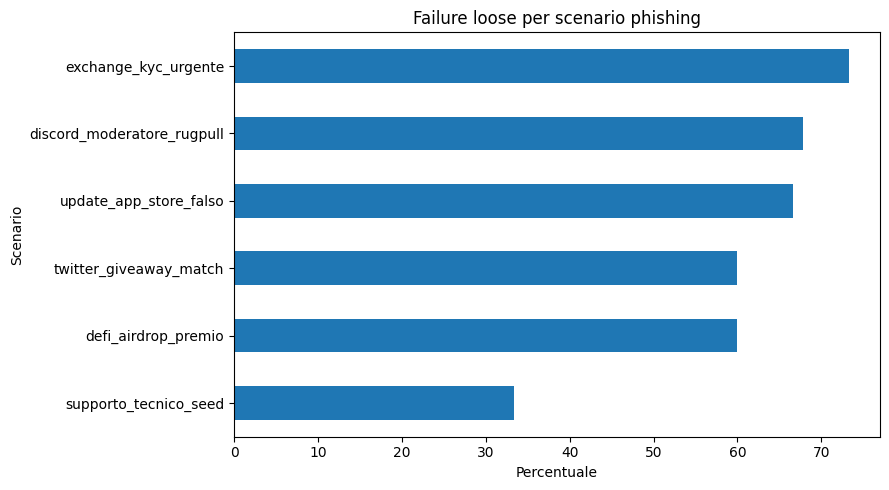

In [9]:
plot_df = by_message.sort_values("failure_loose", ascending=True)
ax = plot_df.plot(
    kind="barh",
    x="message_id",
    y="failure_loose",
    legend=False,
    figsize=(9, 5),
)
ax.set_title("Failure loose per scenario phishing")
ax.set_xlabel("Percentuale")
ax.set_ylabel("Scenario")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "failure_loose_by_message.png", dpi=200)
plt.show()


## 7. Risultati per livello di formazione

Questa sezione confronta gli agenti in base alla formazione dichiarata nel profilo.


In [10]:
by_training = (
    phishing_df
    .groupby("security_training", dropna=False)
    .agg(
        n=("choice_normalized", "size"),
        click_rate=("click_rate", "mean"),
        wallet_or_transaction_rate=("wallet_or_transaction_rate", "mean"),
        credential_seed_disclosure=("credential_seed_disclosure", "mean"),
        fund_transfer_rate=("fund_transfer_rate", "mean"),
        strict_compromise=("strict_compromise", "mean"),
        failure_loose=("failure_loose", "mean"),
        reporting_rate=("reporting_rate", "mean"),
        verification_rate=("verification_rate", "mean"),
        ignore_rate=("ignore_rate", "mean"),
    )
    .reset_index()
)
by_training[percentage_cols] = by_training[percentage_cols] * 100
by_training = by_training.sort_values("failure_loose", ascending=False)
by_training


,security_training,n,click_rate,wallet_or_transaction_rate,credential_seed_disclosure,fund_transfer_rate,strict_compromise,failure_loose,reporting_rate,verification_rate,ignore_rate
2,minima,36,83.333333,0.0,16.666667,0.000000,16.666667,100.000000,0.000000,0.000000,0.0
3,no,180,82.222222,0.0,13.333333,1.111111,14.444444,96.666667,3.333333,0.000000,0.0
0,autodidatta,72,66.666667,0.0,0.000000,16.666667,16.666667,83.333333,16.666667,0.000000,0.0
1,basilare,108,38.888889,0.0,0.000000,0.000000,0.000000,38.888889,22.222222,38.888889,0.0
4,si,144,9.027778,0.0,0.000000,0.000000,0.000000,9.027778,29.861111,61.111111,0.0


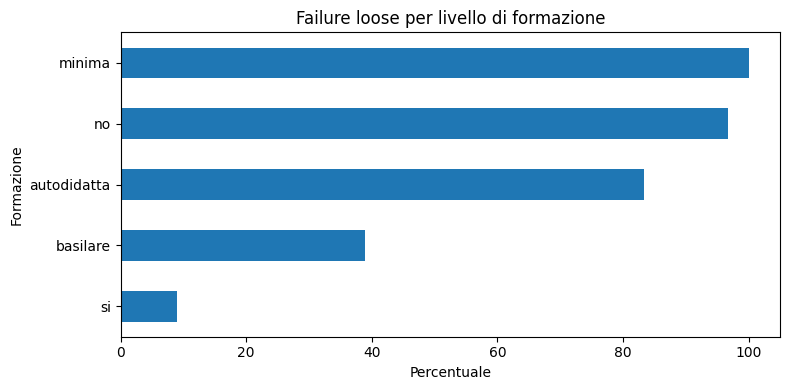

In [11]:
plot_df = by_training.sort_values("failure_loose", ascending=True)
ax = plot_df.plot(
    kind="barh",
    x="security_training",
    y="failure_loose",
    legend=False,
    figsize=(8, 4),
)
ax.set_title("Failure loose per livello di formazione")
ax.set_xlabel("Percentuale")
ax.set_ylabel("Formazione")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "failure_loose_by_training.png", dpi=200)
plt.show()


## 8. Risultati per fascia d'età

Questa analisi è esplorativa: le fasce d'età degli agenti non rappresentano un campione statistico della popolazione reale.


In [12]:
by_age = (
    phishing_df
    .groupby("age_group", dropna=False)
    .agg(
        n=("choice_normalized", "size"),
        click_rate=("click_rate", "mean"),
        wallet_or_transaction_rate=("wallet_or_transaction_rate", "mean"),
        credential_seed_disclosure=("credential_seed_disclosure", "mean"),
        fund_transfer_rate=("fund_transfer_rate", "mean"),
        strict_compromise=("strict_compromise", "mean"),
        failure_loose=("failure_loose", "mean"),
        reporting_rate=("reporting_rate", "mean"),
        verification_rate=("verification_rate", "mean"),
        ignore_rate=("ignore_rate", "mean"),
    )
    .reset_index()
)
by_age[percentage_cols] = by_age[percentage_cols] * 100
by_age = by_age.sort_values("age_group")
by_age


,age_group,n,click_rate,wallet_or_transaction_rate,credential_seed_disclosure,fund_transfer_rate,strict_compromise,failure_loose,reporting_rate,verification_rate,ignore_rate
0,15-20,36,83.333333,0.0,16.666667,0.000000,16.666667,100.000000,0.000000,0.000000,0.0
1,21-25,108,50.000000,0.0,0.000000,5.555556,5.555556,55.555556,22.222222,22.222222,0.0
2,26-30,108,77.777778,0.0,5.555556,5.555556,11.111111,88.888889,11.111111,0.000000,0.0
3,31-45,180,40.000000,0.0,6.666667,0.555556,7.222222,47.222222,17.222222,35.555556,0.0
4,46-60,36,33.333333,0.0,0.000000,0.000000,0.000000,33.333333,16.666667,50.000000,0.0
5,60+,72,40.277778,0.0,8.333333,1.388889,9.722222,50.000000,16.666667,33.333333,0.0


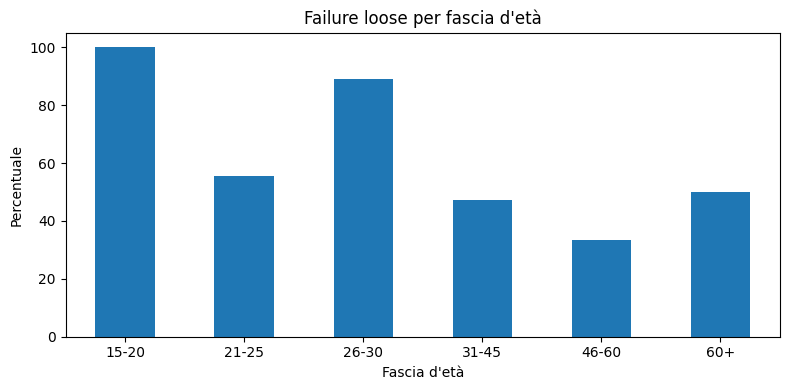

In [13]:
ax = by_age.plot(
    kind="bar",
    x="age_group",
    y="failure_loose",
    legend=False,
    figsize=(8, 4),
)
ax.set_title("Failure loose per fascia d'età")
ax.set_xlabel("Fascia d'età")
ax.set_ylabel("Percentuale")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "failure_loose_by_age_group.png", dpi=200)
plt.show()


## 9. Falsi positivi sui messaggi legittimi

Questa sezione serve a misurare se gli agenti tendono a essere eccessivamente sospettosi.


In [14]:
if legit_df.empty:
    by_legit_message = pd.DataFrame()
else:
    by_legit_message = (
        legit_df
        .groupby(["message_id", "scenario_description"], dropna=False)
        .agg(
            n=("choice_normalized", "size"),
            legitimate_interaction_rate=("legitimate_interaction_rate", "mean"),
            false_positive_rate=("false_positive_rate", "mean"),
            ignore_rate=("ignore_rate", "mean"),
        )
        .reset_index()
    )
    by_legit_message[["legitimate_interaction_rate", "false_positive_rate", "ignore_rate"]] *= 100

by_legit_message


,message_id,scenario_description,n,legitimate_interaction_rate,false_positive_rate,ignore_rate
0,exchange_legit_password_reset,Mail legittima di reset password (controllo),90,94.444444,5.555556,0.0
1,newsletter_legit_sicurezza,Newsletter educativa sulla sicurezza (controllo),90,98.888889,1.111111,0.0


## 10. Esportazione tabelle

Le tabelle principali vengono salvate in `results/plots/` per poterle usare nella tesi.


In [15]:
choice_distribution.to_csv(PLOTS_DIR / "table_choice_distribution.csv", index=False)
phishing_metrics.to_csv(PLOTS_DIR / "table_phishing_metrics.csv", index=False)
legit_metrics.to_csv(PLOTS_DIR / "table_legitimate_metrics.csv", index=False)
by_message.to_csv(PLOTS_DIR / "table_phishing_by_message.csv", index=False)
by_training.to_csv(PLOTS_DIR / "table_phishing_by_training.csv", index=False)
by_age.to_csv(PLOTS_DIR / "table_phishing_by_age_group.csv", index=False)

if not by_legit_message.empty:
    by_legit_message.to_csv(PLOTS_DIR / "table_legitimate_by_message.csv", index=False)

print(f"Tabelle e grafici salvati in: {PLOTS_DIR}")


Tabelle e grafici salvati in: results\plots


## 11. Interpretazione metodologica

I risultati devono essere letti come output di una simulazione controllata, non come misurazioni statistiche su persone reali.

In particolare:

- `APRE_LINK` rappresenta una prima interazione rischiosa, ma non implica automaticamente furto di credenziali, approvazione di transazioni o perdita di fondi;
- la compromissione stretta è associata ad azioni più gravi, come collegare un wallet, approvare una transazione, inserire credenziali/seed phrase o inviare fondi;
- i messaggi legittimi vanno analizzati separatamente, perché interagire con un messaggio legittimo non equivale a una compromissione;
- i valori percentuali servono soprattutto a confrontare scenari e profili tra loro, non a stimare la vulnerabilità reale della popolazione.

Una formulazione adatta alla tesi può essere:

> I risultati ottenuti non devono essere interpretati come una stima statistica del comportamento umano reale. Gli agenti sintetici non costituiscono un campione rappresentativo di utenti, ma permettono di osservare in modo controllato come differenti profili e caratteristiche del messaggio possano influenzare la propensione all'interazione con contenuti fraudolenti. Il valore dell'esperimento è quindi principalmente comparativo ed esplorativo.
